Error máximo en la conservación de la masa (S+E+I+R): 4.47035e-08


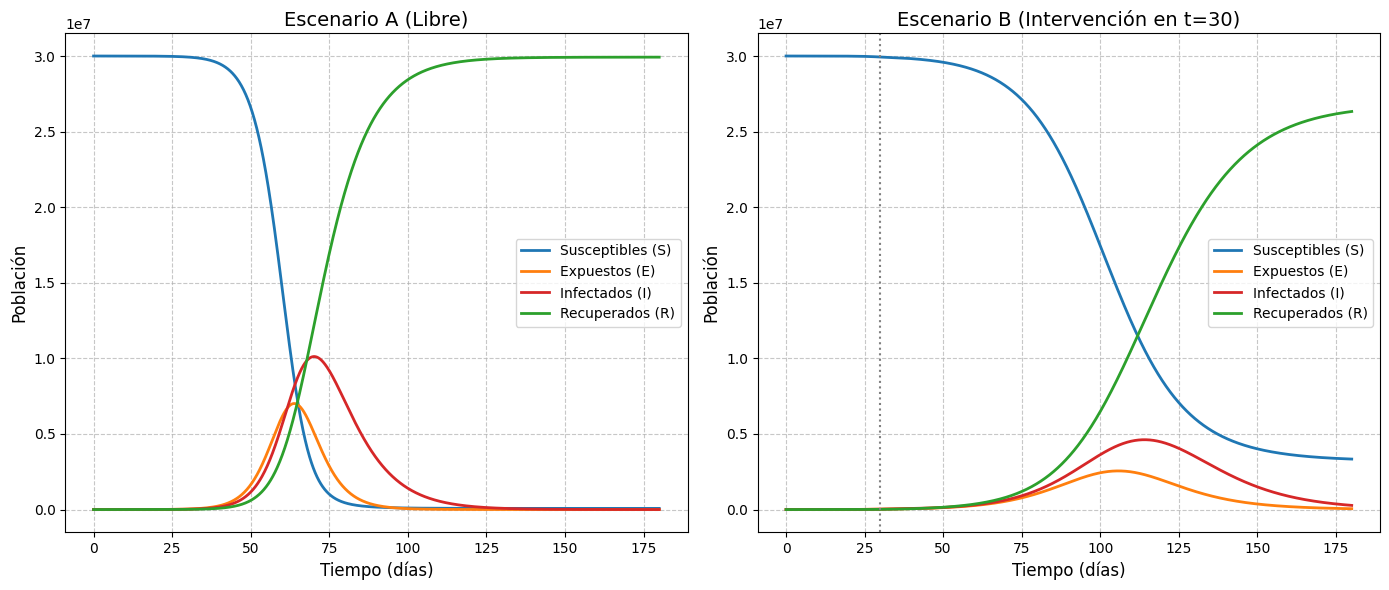

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Parámetros Iniciales y Biológicos

N = 3e7          # Población total
I0 = 100         # Infectados iniciales
E0 = 0           # Expuestos iniciales
R0 = 0           # Recuperados iniciales
S0 = N - I0      # Susceptibles iniciales

# Vector de estado inicial: [S, E, I, R]
y0 = np.array([S0, E0, I0, R0])

sigma = 0.2      # Tasa de incubación
gamma = 0.1      # Tasa de recuperación

# Parámetros de simulación
t_max = 180      # Días de simulación
h = 0.1          # Tamaño del paso temporal
pasos = int(t_max / h)
tiempos = np.linspace(0, t_max, pasos)


# 2. Definición del Modelo y RK4 Manual

def derivadas_seir(t, y, beta):
    """Calcula las tasas de cambio para cada compartimiento del SEIR."""
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = (beta * S * I / N) - (sigma * E)
    dIdt = (sigma * E) - (gamma * I)
    dRdt = gamma * I
    return np.array([dSdt, dEdt, dIdt, dRdt])

def paso_rk4(t, y, h, beta):
    """Calcula el siguiente estado usando Runge-Kutta de 4to orden."""
    k1 = derivadas_seir(t, y, beta)
    k2 = derivadas_seir(t + h/2, y + (h/2)*k1, beta)
    k3 = derivadas_seir(t + h/2, y + (h/2)*k2, beta)
    k4 = derivadas_seir(t + h, y + h*k3, beta)
    return y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)


# 3. Ejecución de los Escenarios

def simular_escenario(escenario_tipo):
    """Ejecuta la integración numérica sobre el dominio temporal."""
    Y = np.zeros((pasos, 4))
    Y[0] = y0

    for i in range(1, pasos):
        t_actual = tiempos[i-1]

        # Ajuste dinámico de beta según el escenario
        if escenario_tipo == 'A':
            beta_actual = 0.6
        elif escenario_tipo == 'B':
            beta_actual = 0.6 if t_actual < 30 else 0.25

        Y[i] = paso_rk4(t_actual, Y[i-1], h, beta_actual)

    return Y

# Ejecutar simulaciones
resultados_A = simular_escenario('A')
resultados_B = simular_escenario('B')


# 4. Análisis de Conservación

poblacion_total_A = np.sum(resultados_A, axis=1)
error_maximo = np.max(np.abs(poblacion_total_A - N))
print(f"Error máximo en la conservación de la masa (S+E+I+R): {error_maximo:.5e}")


# 5. Visualización Gráfica

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
etiquetas = ['Susceptibles (S)', 'Expuestos (E)', 'Infectados (I)', 'Recuperados (R)']
colores = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']

for i in range(4):
    ax1.plot(tiempos, resultados_A[:, i], label=etiquetas[i], color=colores[i], linewidth=2)
    ax2.plot(tiempos, resultados_B[:, i], label=etiquetas[i], color=colores[i], linewidth=2)

# Configuración de las gráficas
for ax, titulo in zip([ax1, ax2], ['Escenario A (Libre)', 'Escenario B (Intervención en t=30)']):
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel('Tiempo (días)', fontsize=12)
    ax.set_ylabel('Población', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='best')
    if ax == ax2: ax.axvline(x=30, color='gray', linestyle=':', label='Inicio confinamiento')

plt.tight_layout()
plt.show()

In [4]:

# Respuestas a Preguntas 3 y 4

print("\n 3. ANÁLISIS DE UMBRAL (R0) ")
R0_A = 0.6 / gamma
R0_B_antes = 0.6 / gamma
R0_B_despues = 0.25 / gamma

print(f"Escenario A (Libre): R0 = {R0_A:.1f}")
print(f"Escenario B (Intervención): R0 inicial = {R0_B_antes:.1f} | R0 post-confinamiento = {R0_B_despues:.1f}")
print("Explicación:")
print("Al reducir beta en t=30, el número reproductivo R0 baja de 6.0 a 2.5.")
print("Aunque la enfermedad sigue activa (R0 > 1), la tasa de nuevas infecciones se ralentiza.")
print("Esto permite que la tasa de recuperación compita mejor contra los nuevos contagios,")
print("agotando la reserva de susceptibles más lentamente y achatando el pico drásticamente.\n")

print(" 4. ANÁLISIS DE CONSERVACIÓN ")
# Calculamos la población total S + E + I + R para cada paso de tiempo
poblacion_A = np.sum(resultados_A, axis=1)
poblacion_B = np.sum(resultados_B, axis=1)

# Verificamos la diferencia máxima respecto a la población inicial N
error_max_A = np.max(np.abs(poblacion_A - N))
error_max_B = np.max(np.abs(poblacion_B - N))

print(f"Población teórica inicial N: {N}")
print(f"Desviación máxima en Escenario A durante toda la simulación: {error_max_A:.2e}")
print(f"Desviación máxima en Escenario B durante toda la simulación: {error_max_B:.2e}")
print("Conclusión: Numéricamente, la desviación es del orden del error de precisión de coma flotante.")
print("Por lo tanto, se demuestra que la población S+E+I+R permanece constante en cada iteración de RK4.")


 3. ANÁLISIS DE UMBRAL (R0) 
Escenario A (Libre): R0 = 6.0
Escenario B (Intervención): R0 inicial = 6.0 | R0 post-confinamiento = 2.5
Explicación:
Al reducir beta en t=30, el número reproductivo R0 baja de 6.0 a 2.5.
Aunque la enfermedad sigue activa (R0 > 1), la tasa de nuevas infecciones se ralentiza.
Esto permite que la tasa de recuperación compita mejor contra los nuevos contagios,
agotando la reserva de susceptibles más lentamente y achatando el pico drásticamente.

 4. ANÁLISIS DE CONSERVACIÓN 
Población teórica inicial N: 30000000.0
Desviación máxima en Escenario A durante toda la simulación: 4.47e-08
Desviación máxima en Escenario B durante toda la simulación: 6.71e-08
Conclusión: Numéricamente, la desviación es del orden del error de precisión de coma flotante.
Por lo tanto, se demuestra que la población S+E+I+R permanece constante en cada iteración de RK4.
